
Total mass:

t=     0.0   M=1.000004
t=   100.0   M=1.000004
t=   500.0   M=1.000004
t=  1000.0   M=1.000004
t=  2000.0   M=1.000004
t=  5000.0   M=1.000004
t= 10000.0   M=1.000004


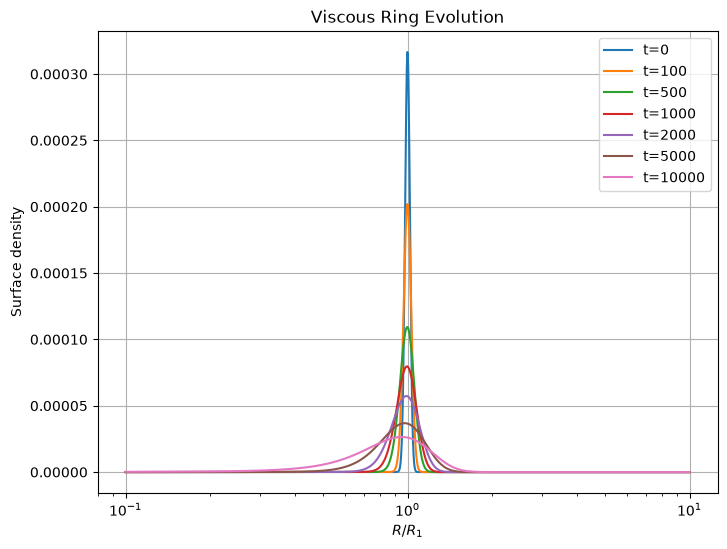

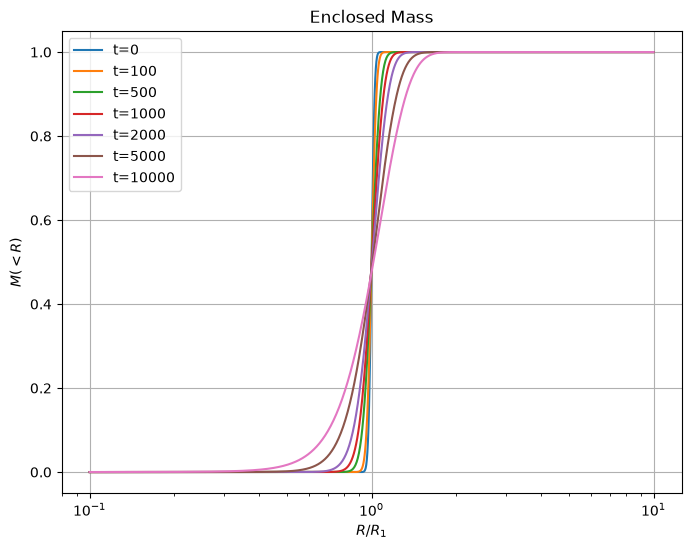

In [1]:
#constant viscosity
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


nr = 3000

r_min = 1e-2
r_max = 1e4

r = np.logspace(
    np.log10(r_min),
    np.log10(r_max),
    nr
)


nu = 0.01

R1 = 100.0          # ring location
sigma_ring = 2.0    # width of Gaussian


Sigma0 = (1/(2*np.pi*R1)* 1/(np.sqrt(2*np.pi)*sigma_ring)* np.exp(-(r-R1)**2/(2*sigma_ring**2)))




def dSigma_dt(t, Sigma):

    A = nu * Sigma * np.sqrt(r)

    dA_dr = np.gradient(A, r, edge_order=2)

    B = np.sqrt(r) * dA_dr

    dB_dr = np.gradient(B, r, edge_order=2)

    dSigma = (3.0/r) * dB_dr

    # inner boundary
    #dSigma[0] = 0.0

    # outer boundary
    #dSigma[-1] = dSigma[-2]

    return dSigma

t_eval = [0,100,500,1000,2000,5000,10000]


sol = solve_ivp(
    dSigma_dt,
    (0,10000),
    Sigma0,
    method="BDF",
    t_eval=t_eval,
    rtol=1e-6,
    atol=1e-9
)

print("\nTotal mass:\n")

for i,t in enumerate(sol.t):

    M = np.trapezoid(2*np.pi*r*sol.y[:,i],r)

    print(f"t={t:8.1f}   M={M:.6f}")


mask = ((r/R1 > 0.1) & (r/R1 < 10))

plt.figure(figsize=(8,6))

for i,t in enumerate(sol.t):

    plt.plot(
        r[mask]/R1,
        sol.y[mask,i],
        label=f"t={t:.0f}"
    )

plt.xscale("log")
plt.xlabel(r"$R/R_1$")
plt.ylabel(r"Surface density")
plt.title("Viscous Ring Evolution")
plt.grid()
plt.legend()

plt.show()


plt.figure(figsize=(8,6))

for i,t in enumerate(sol.t):

    Sigma = sol.y[:,i]

    Menc = np.zeros_like(r)

    Menc[1:] = np.cumsum(
        0.5 * (
            2*np.pi*r[1:]*Sigma[1:]
            +
            2*np.pi*r[:-1]*Sigma[:-1]
        )
        * np.diff(r)
    )

    plt.plot(
        r[mask]/R1,
        Menc[mask],
        label=f"t={t:.0f}"
    )

plt.xscale("log")
plt.xlabel(r"$R/R_1$")
plt.ylabel(r"$M(<R)$")
plt.title("Enclosed Mass")
plt.grid()
plt.legend()

plt.show()

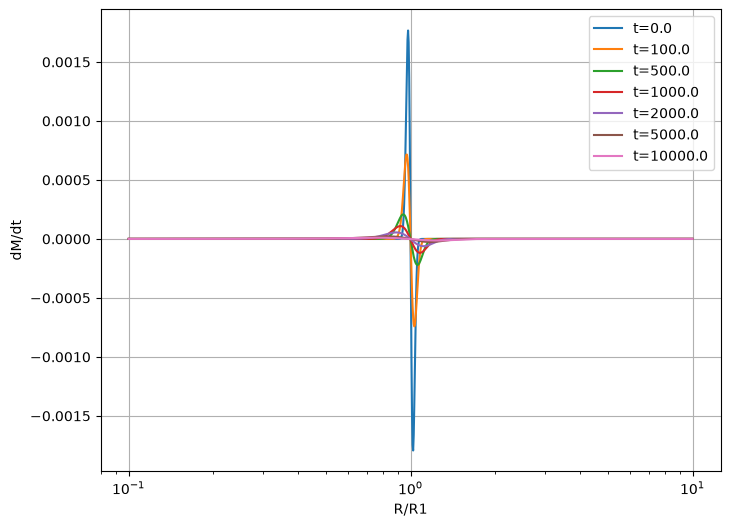

In [7]:
plt.figure(figsize=(8,6))
R1_norm=r[mask]/R1
for i, t in enumerate(sol.t):

    Sigma = sol.y[:, i]

    D = nu * Sigma * np.sqrt(r)

    dD_dr = np.gradient(D, r,edge_order=2)

    Mdot = 6*np.pi*np.sqrt(r)*dD_dr

 

    plt.plot(R1_norm, Mdot[mask], label=f"t={t:.1f}")


plt.xlabel("R/R1")
plt.ylabel("dM/dt")
#plt.ylim(-0.01,0.01)
#plt.xlim(-0.5,0.5)
plt.xscale("log")
#plt.yscale("log")
#plt.ylim(-2.5e-3,2.5e-3)
#plt.xlim(-1,1)
plt.legend()
plt.grid()
plt.show()

ts = 33.333333333333336

Mass:

T=1.0   M=0.63417
T=2.0   M=0.52578
T=4.0   M=0.46707
T=8.0   M=0.42870
T=16.0   M=0.46113


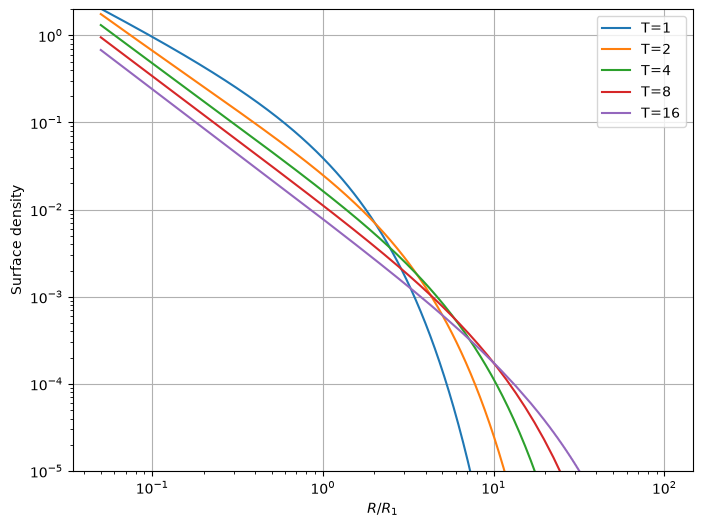

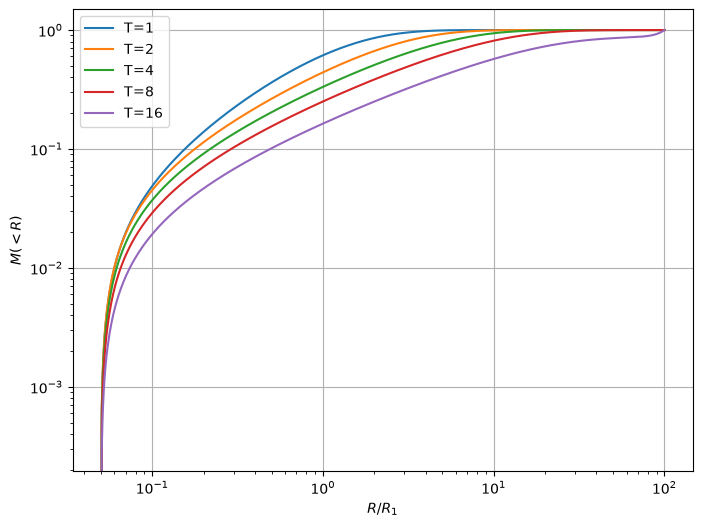

In [8]:
#linear viscosity
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


R1 = 1.0

nr = 600
r_min = 0.05*R1
r_max = 100*R1

r = np.logspace(
    np.log10(r_min),
    np.log10(r_max),
    nr
)

R = r/R1

nu0 = 0.01
C=0.01
nu = nu0*r

gamma = 1.0

nu1 = nu0*R1

ts = R1**2 / (3*(2-gamma)**2*nu1)

print("ts =", ts)

Sigma0 = (
    C/(3*np.pi*nu1)
    * R**(-gamma)
    * np.exp(-R**(2-gamma))
)



def dSigma_dt(t,Sigma):

    A = nu*Sigma*np.sqrt(r)

    dA_dr = np.gradient(
        A,
        r,
        edge_order=2
    )

    B = np.sqrt(r)*dA_dr

    dB_dr = np.gradient(
        B,
        r,
        edge_order=2
    )

    dSigma = (3/r)*dB_dr

    #dSigma[0] = 0.0
    #dSigma[-1] = dSigma[-2]

    return dSigma


T_values = [1,2,4,8,16]

t_eval = (np.array(T_values)-1)*ts


sol = solve_ivp(
    dSigma_dt,
    (0,t_eval[-1]),
    Sigma0,
    t_eval=t_eval,
    method="BDF",
    rtol=1e-6,
    atol=1e-9
)


print("\nMass:\n")

for i,t in enumerate(sol.t):

    M = np.trapezoid(
        2*np.pi*r*sol.y[:,i],
        r
    )

    print(f"T={1+t/ts:.1f}   M={M:.5f}")

plt.figure(figsize=(8,6))

for i,t in enumerate(sol.t):

    T = 1+t/ts

    plt.plot(
        R,
        sol.y[:,i],
        label=f"T={T:.0f}"
    )

plt.xscale("log")
plt.yscale("log")
plt.ylim(1e-5,2)
plt.xlabel(r"$R/R_1$")
plt.ylabel(r"Surface density")
plt.grid()
plt.legend()

plt.show()

plt.figure(figsize=(8,6))

for i,t in enumerate(sol.t):

    Sigma = sol.y[:,i]

    Menc = np.zeros_like(r)

    Menc[1:] = np.cumsum(
        0.5*(
            2*np.pi*r[1:]*Sigma[1:]
            +
            2*np.pi*r[:-1]*Sigma[:-1]
        )
        * np.diff(r)
    )

    Menc /= Menc[-1]

    plt.plot(
        R,
        Menc,
        label=f"T={1+t/ts:.0f}"
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$R/R_1$")
plt.ylabel(r"$M(<R)$")

plt.grid()
plt.legend()

plt.show()

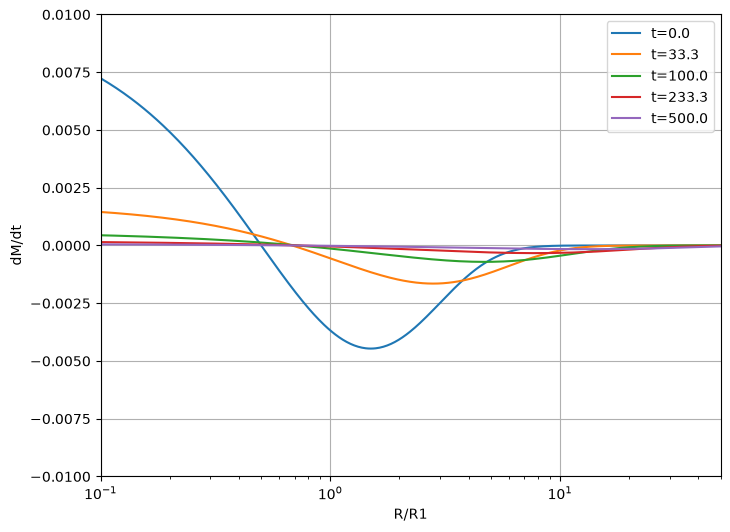

In [4]:
plt.figure(figsize=(8,6))
R1_norm=r/R1
for i, t in enumerate(sol.t):

    Sigma = sol.y[:, i]

    D = nu * Sigma * np.sqrt(r)

    dD_dr = np.gradient(D, r,edge_order=2)

    Mdot = 6*np.pi*np.sqrt(r)*dD_dr

 

    plt.plot(R1_norm, Mdot, label=f"t={t:.1f}")


plt.xlabel("R/R1")
plt.ylabel("dM/dt")
plt.ylim(-0.01,0.01)
plt.xlim(0.1,50)
plt.xscale("log")
#plt.yscale("log")
#plt.ylim(-2.5e-3,2.5e-3)
#plt.xlim(-1,1)
plt.legend()
plt.grid()
plt.show()